----- Interval μ values (Xmin = X0) -----
Interval 1: t = [0.00, 0.54] h | S = 137.0 g/L | mu = 0.8961 1/h
Interval 2: t = [0.54, 0.90] h | S = 114.0 g/L | mu = 0.8454 1/h
Interval 3: t = [0.90, 1.23] h | S = 90.0 g/L | mu = 0.8889 1/h
Interval 4: t = [1.23, 1.58] h | S = 43.0 g/L | mu = 0.7143 1/h
Interval 5: t = [1.58, 1.95] h | S = 29.0 g/L | mu = 0.5461 1/h
Interval 6: t = [1.95, 2.33] h | S = 9.0 g/L | mu = 0.1354 1/h
Interval 7: t = [2.33, 2.70] h | S = 2.0 g/L | mu = 0.0529 1/h

----- Lineweaver–Burk fit (intervals 1–5) -----
m = 25.2979  (h·g/L)
b = 0.9013  (h)
mu_max = 1.109  1/h
Ks = 28.07  g/L
R^2 = 0.948

----- Doubling time -----
td (using mu_max) = 0.625 h  = 37.5 min


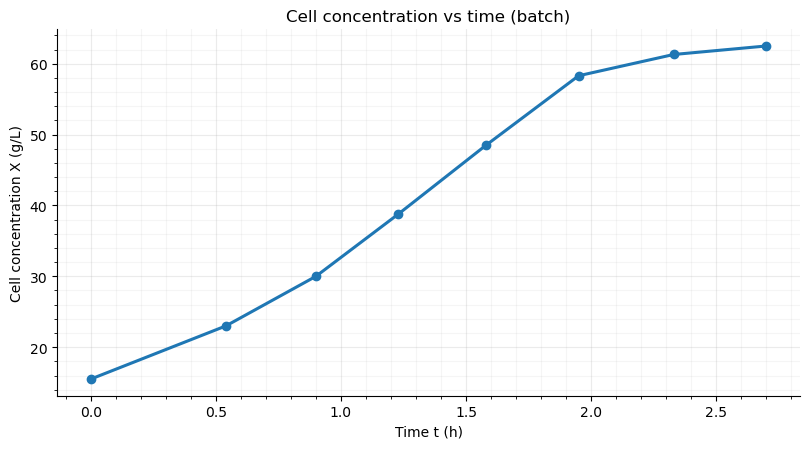

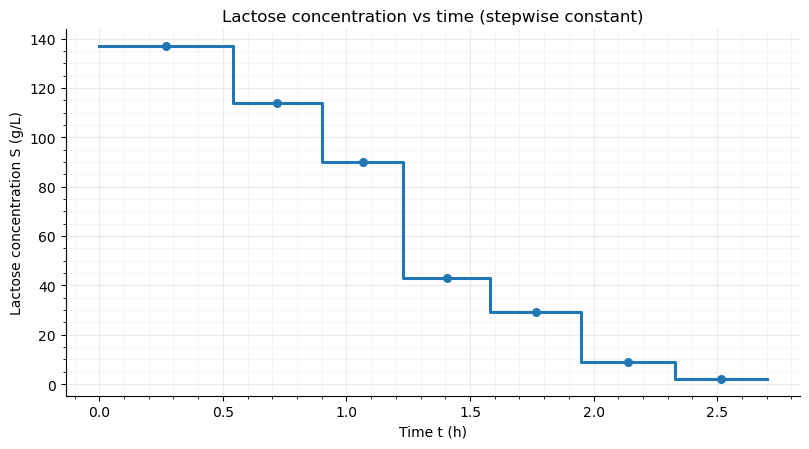

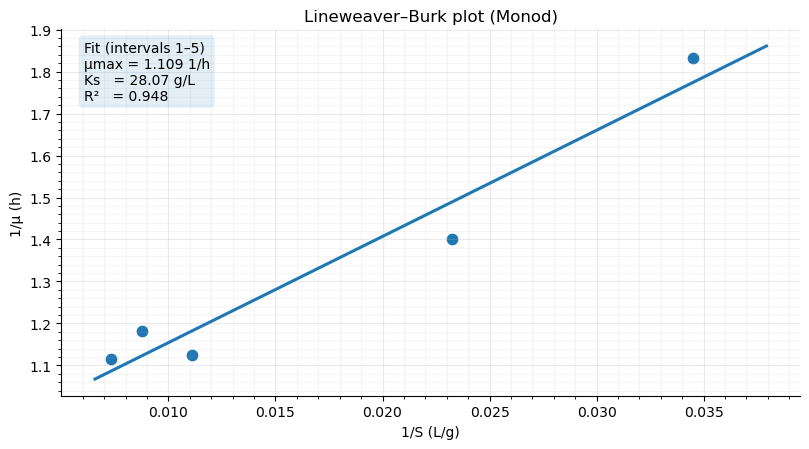

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# EXERCISE 2 — Monod kinetics from batch data
# Using the formula given in the statement:
#   mu = (1 / X_min) * (dX/dt)  with  X_min = X0
# ============================================================

# ----------------------------
# Data (hard-coded)
# ----------------------------
t0 = np.array([0.00, 0.54, 0.90, 1.23, 1.58, 1.95, 2.33])
t1 = np.array([0.54, 0.90, 1.23, 1.58, 1.95, 2.33, 2.70])

X0 = np.array([15.5, 23.0, 30.0, 38.8, 48.5, 58.3, 61.3])  # g/L
X1 = np.array([23.0, 30.0, 38.8, 48.5, 58.3, 61.3, 62.5])  # g/L

# Lactose concentration (constant in each interval)
S = np.array([137., 114., 90., 43., 29., 9., 2.])          # g/L

# ----------------------------
# μ calculation per interval (Xmin = X0)
# ----------------------------
dt = t1 - t0
dXdt = (X1 - X0) / dt                 # g/L/h
mu = (1.0 / X0) * dXdt                # 1/h  (Xmin = X0)

# ----------------------------
# Nice plotting helper
# ----------------------------
def beautify_axes(ax):
    ax.grid(True, which="major", alpha=0.25)
    ax.grid(True, which="minor", alpha=0.12)
    ax.minorticks_on()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# ============================================================
# A) Plot X(t) and S(t)
# ============================================================

# X(t) piecewise linear (connect interval endpoints)
t_plot = np.r_[t0, t1[-1]]
X_plot = np.r_[X0, X1[-1]]

fig, ax = plt.subplots(figsize=(8.2, 4.6))
ax.plot(t_plot, X_plot, marker="o", linewidth=2.2, markersize=6)
ax.set_xlabel("Time t (h)")
ax.set_ylabel("Cell concentration X (g/L)")
ax.set_title("Cell concentration vs time (batch)")
beautify_axes(ax)
plt.tight_layout()

# S(t) step plot (constant on each interval)
t_step = np.r_[t0, t1[-1]]
S_step = np.r_[S, S[-1]]

fig, ax = plt.subplots(figsize=(8.2, 4.6))
ax.step(t_step, S_step, where="post", linewidth=2.2)
ax.scatter((t0 + t1)/2, S, s=30)  # markers at mid-interval to show the constant value
ax.set_xlabel("Time t (h)")
ax.set_ylabel("Lactose concentration S (g/L)")
ax.set_title("Lactose concentration vs time (stepwise constant)")
beautify_axes(ax)
plt.tight_layout()

# ============================================================
# A) Lineweaver–Burk: 1/μ vs 1/S
# Work only with exponential phase:
# default choice: intervals 1–5  -> indices 0..4 (adjust if needed)
# ============================================================

idx = np.array([0, 1, 2, 3, 4])

x = 1.0 / S[idx]       # 1/S
y = 1.0 / mu[idx]      # 1/mu

# Fit y = m x + b (least squares)
A = np.vstack([x, np.ones_like(x)]).T
m, b = np.linalg.lstsq(A, y, rcond=None)[0]

# Monod LB form:
# 1/mu = (Ks/mu_max)(1/S) + 1/mu_max
mu_max = 1.0 / b
Ks = m * mu_max

# R^2 for fit quality
yhat = m*x + b
ss_res = np.sum((y - yhat)**2)
ss_tot = np.sum((y - np.mean(y))**2)
r2 = 1 - ss_res/ss_tot

# Plot LB with fitted line
xx = np.linspace(x.min()*0.9, x.max()*1.1, 250)

fig, ax = plt.subplots(figsize=(8.2, 4.6))
ax.scatter(x, y, s=55)
ax.plot(xx, m*xx + b, linewidth=2.2)
ax.set_xlabel("1/S (L/g)")
ax.set_ylabel("1/μ (h)")
ax.set_title("Lineweaver–Burk plot (Monod)")
beautify_axes(ax)

# Annotate fit
text = (
    f"Fit (intervals 1–5)\n"
    f"μmax = {mu_max:.3f} 1/h\n"
    f"Ks   = {Ks:.2f} g/L\n"
    f"R²   = {r2:.3f}"
)
ax.text(0.03, 0.97, text, transform=ax.transAxes, va="top", ha="left",
        bbox=dict(boxstyle="round,pad=0.35", alpha=0.12, edgecolor="none"))
plt.tight_layout()

# ============================================================
# 😎 Doubling time
# td = ln(2)/μ  (choose μ = μmax as "best exponential phase" estimate)
# ============================================================
td = np.log(2) / mu_max

# ----------------------------
# Print results + a small μ table
# ----------------------------
print("----- Interval μ values (Xmin = X0) -----")
for i in range(len(mu)):
    print(f"Interval {i+1}: t = [{t0[i]:.2f}, {t1[i]:.2f}] h | S = {S[i]:.1f} g/L | mu = {mu[i]:.4f} 1/h")

print("\n----- Lineweaver–Burk fit (intervals 1–5) -----")
print(f"m = {m:.4f}  (h·g/L)")
print(f"b = {b:.4f}  (h)")
print(f"mu_max = {mu_max:.3f}  1/h")
print(f"Ks = {Ks:.2f}  g/L")
print(f"R^2 = {r2:.3f}")

print("\n----- Doubling time -----")
print(f"td (using mu_max) = {td:.3f} h  = {td*60:.1f} min")

plt.show()


Fit on intervals 1–5:
m = 25.2979  (h·g/L)
b = 0.9013  (h)
mu_max = 1.109  1/h
Ks = 28.07  g/L
R^2 = 0.948
Doubling time using mu_max: 0.625 h = 37.5 min
